In [17]:
# Helper cell: set up imports and paths for modules

import sys

modules_path = "/home/stages/chau/projects/internship-bezout/src/modules"
if modules_path not in sys.path:
    sys.path.insert(0, modules_path)

import importlib

import stochastic_recurrence
import find_power
import monte_carlo
import operators

importlib.reload(stochastic_recurrence)
importlib.reload(find_power)
importlib.reload(monte_carlo)
importlib.reload(operators)

from stochastic_recurrence import simulate_Yns_independent, compute_Yns_numba, simulate_Yns, simulate_Yns_numba
from find_power import find_mean_preserving_alpha
from monte_carlo import plot_distribution, wasserstein
from operators import T_for_positive, T, T_independent

from utils import latex_print

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import beta


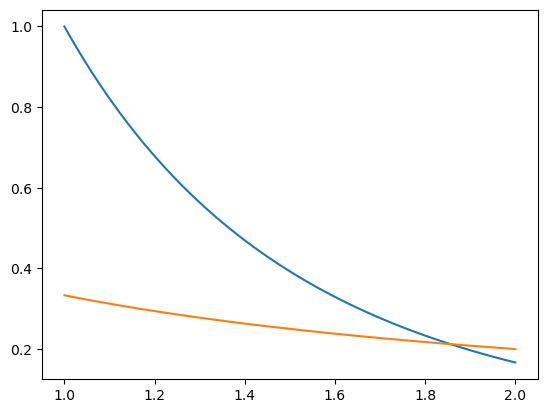

In [6]:
betas = [beta(x, x) for x in np.linspace(1, 2, 100)]
refs = [1/(2*x + 1) for x in np.linspace(1, 2, 100)]

plt.plot(np.linspace(1, 2, 100), betas)
plt.plot(np.linspace(1, 2, 100), refs)
plt.show()

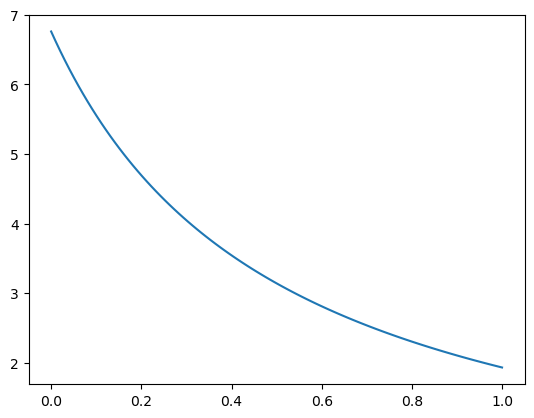

np.float64(1.9322753664019785)

In [12]:
u = 0.5
v = 0.3
test = [2*(u+v)*beta(x+1, x+1)/(1-2*(u+v)/(2*x+1)) for x in np.linspace(2*u + v - 0.9, 2*(u+v) - 1, 100)]
plt.plot(np.linspace(0, 1, 100), test)
plt.show()

x = 2*(u+v) - 1
2*(u+v)*beta(x+1, x+1)/(1-2*(u+v)/(2*x+1))

In [30]:
def less_than_in_convex_order(X, Y, num_samples=100000):
    """Check if X is less than Y in convex order by sampling."""
    samples_X = np.random.choice(X, size=num_samples, replace=True)
    samples_Y = np.random.choice(Y, size=num_samples, replace=True)

    for t in np.linspace(0, max(max(X), max(Y)), 100):
        if np.mean(np.maximum(samples_X - t, 0)) <= np.mean(np.maximum(samples_Y - t, 0)):
            return False
    
    return True

Iteration 1000/50000 completed.
Iteration 2000/50000 completed.
Iteration 3000/50000 completed.
Iteration 4000/50000 completed.
Iteration 5000/50000 completed.
Iteration 6000/50000 completed.
Iteration 7000/50000 completed.
Iteration 8000/50000 completed.
Iteration 9000/50000 completed.
Iteration 10000/50000 completed.
Iteration 11000/50000 completed.
Iteration 12000/50000 completed.
Iteration 13000/50000 completed.
Iteration 14000/50000 completed.
Iteration 15000/50000 completed.
Iteration 16000/50000 completed.
Iteration 17000/50000 completed.
Iteration 18000/50000 completed.
Iteration 19000/50000 completed.
Iteration 20000/50000 completed.
Iteration 21000/50000 completed.
Iteration 22000/50000 completed.
Iteration 23000/50000 completed.
Iteration 24000/50000 completed.
Iteration 25000/50000 completed.
Iteration 26000/50000 completed.
Iteration 27000/50000 completed.
Iteration 28000/50000 completed.
Iteration 29000/50000 completed.
Iteration 30000/50000 completed.
Iteration 31000/500

Text(0.5, 1.0, 'Expected value of Y_n across iterations')

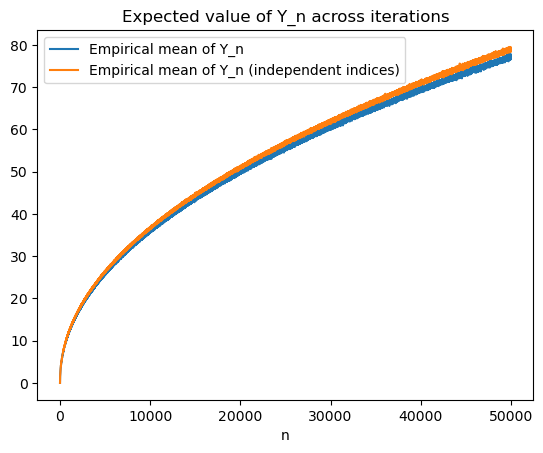

In [34]:
N = 50000

Yns_independent = simulate_Yns_independent(N, u=0.5, v=0.3, num_particles=100000)
Yns = simulate_Yns(N, u=0.5, v=0.3, num_particles=100000)

EYns_independent = np.mean(Yns_independent, axis=1)
EYns = np.mean(Yns, axis=1)


plt.plot(EYns, label="Empirical mean of Y_n")
plt.plot(EYns_independent, label="Empirical mean of Y_n (independent indices)")
plt.legend()
plt.xlabel("n")
plt.title("Expected value of Y_n across iterations")

In [ ]:
u = 0.5
v = 0.3

num_particles = 2000000

op = lambda x, a: T(x, u, v, a)
op_ind = lambda x, a: T_independent(x, u, v, a)

X_init = np.ones(num_particles)
# X = np.random.uniform(0, 2, size=num_particles)  # Start with a uniform distribution on [0, 2]
alpha = find_mean_preserving_alpha(X_init, op, bracket=[2*u+v-1, 2*(u+v)-1], num_iters=50)

alphas = [alpha]
alphas_ind = [alpha]

moments = [np.mean(X_init**2)]
moments_ind = [np.mean(X_init**2)]


for i in range(50):
    X_next = op(X, alpha)
    X_next = X_next/np.mean(X_next)
    alpha = find_mean_preserving_alpha(X_next, op, bracket=[2*u+v-1, 2*(u+v)-1])
    alphas.append(alpha)
    moments.append(np.mean(X_next**2))

    X_next_ind = op_ind(X_init, alpha)
    X_next_ind = X_next_ind/np.mean(X_next_ind)
    alphas_ind = find_mean_preserving_alpha(X_next_ind, op_ind, bracket=[0.1, 1])
    alphas_ind.append(alphas_ind)
    moments_ind.append(np.mean(X_next_ind**2))

    print(f"{f'Iteration {i+1}/50':<18} | alpha = {alpha:<8.4f} | alpha_independent = {alphas_ind:<8.4f} | moment = {moments[-1]:<8.4f} | moment_independent = {moments_ind[-1]:<8.4f}")

    X = X_next

ValueError: f(a) and f(b) must have different signs

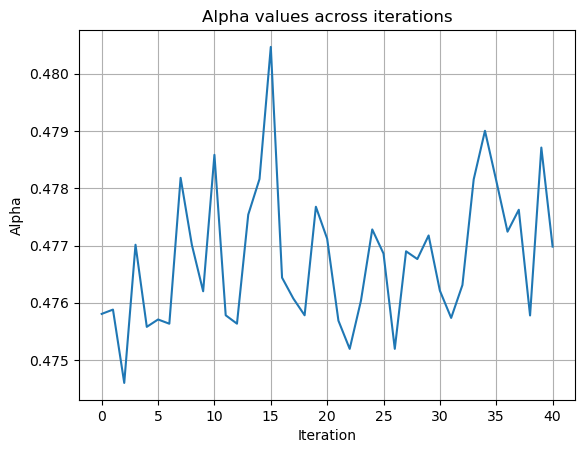

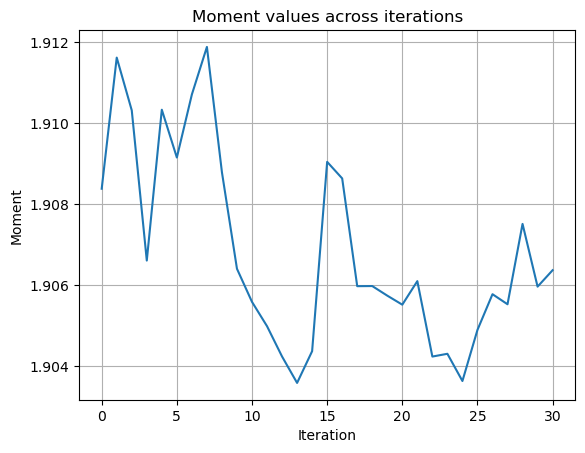

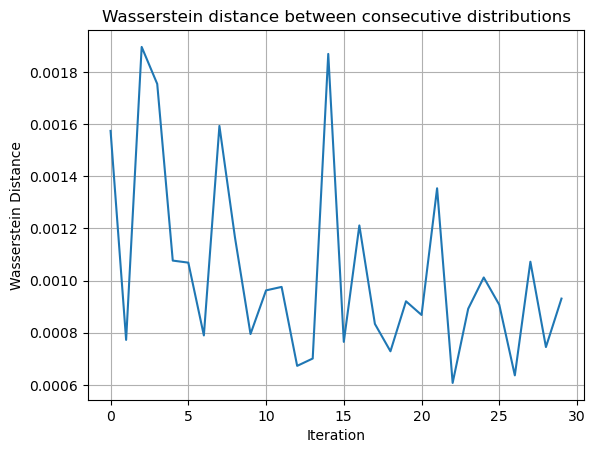

In [15]:
plt.plot(alphas[10:])
plt.xlabel("Iteration")
plt.ylabel("Alpha")
plt.title("Alpha values across iterations")
plt.grid()
plt.show()

plt.plot(moments[20:])
plt.xlabel("Iteration")
plt.ylabel("Moment")
plt.title("Moment values across iterations")
plt.grid()
plt.show()

plt.plot(distances[20:])
plt.xlabel("Iteration")
plt.ylabel("Wasserstein Distance")
plt.title("Wasserstein distance between consecutive distributions")
plt.grid()
plt.show()